# CST8507 Lab 1: Zipf's Law and Text Analysis

**Author:** Peng Wang  
**Section:** 101  
**Date:** 2026-01-20

## Description

This program analyzes word frequency distributions in two different text corpora (literary and informational) to empirically verify Zipf's Law. It performs tokenization, frequency analysis, and comparative studies including stability testing with stopword removal and part-of-speech filtering.

## Innovations

- Automated comparative analysis with statistical metrics
- Comprehensive visualization with multiple subplots
- Robust preprocessing pipeline with error handling

## Step 1: Import required libraries

In [8]:
import string
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import gutenberg, stopwords
from scipy import stats

# Ensure required NLTK data is available
# 确保所需的 NLTK 语料/模型已安装可用
# Uncomment these lines on first run to download necessary data
# 首次运行时如缺少资源，请取消注释以下下载语句
# nltk.download('gutenberg')
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger')

# 名词解释（本实验中会反复出现）
# - token（词元/符号）：分词后得到的最小处理单位（这里基本等同于“单词”）
# - corpus（语料库）：用于分析的一批文本集合（这里用 NLTK Gutenberg 的文本）
# - vocabulary（词表/词汇量）：去重后的 token 集合大小
# - frequency（词频）：某个词在语料中出现的次数
# - rank（排名）：按词频从高到低排序后，词的名次（最高频词 rank=1）
# - Zipf's Law（Zipf 定律）：经验规律，通常满足 f(r) ≈ C / r^alpha
# - alpha（α，幂律指数）：控制词频随 rank 衰减的“陡峭程度”（alpha 越大，下降越快）
# - log-log plot（双对数图）：对 rank 和 frequency 同时取对数后作图；若近似直线则符合幂律
# - R^2（决定系数）：线性回归拟合优度，越接近 1 表示越接近一条直线（越符合 Zipf/幂律）
# - stopwords（停用词）：高频但信息量较低的功能词，如 the/and/of...
# - POS tagging（词性标注）：给 token 标注词性（名词/动词/形容词等）

def tokenize_and_clean(text):
    """
    Tokenize text and perform basic cleaning.
    对文本分词并进行基础清洗。
    
    Args:
        text (str): Raw text to tokenize
                   待处理的原始文本
    
    Returns:
        list: List of cleaned tokens (lowercase, alphabetic only)
              清洗后的 token 列表（小写，仅保留字母单词）
    """
    # Tokenize the text
    # 分词：将原始字符串切分为 token 序列
    tokens = word_tokenize(text)
    
    # Clean tokens: lowercase and keep only alphabetic words
    # 清洗：统一转小写，并仅保留纯字母 token（过滤标点、数字等）
    cleaned_tokens = [token.lower() for token in tokens 
                     if token.isalpha()]
    
    return cleaned_tokens


def analyze_frequency(tokens):
    """
    Analyze word frequency distribution.
    统计词频分布。
    
    Args:
        tokens (list): List of word tokens
                      token 列表
    
    Returns:
        tuple: (FreqDist object, sorted list of (word, frequency) tuples, DataFrame)
               (FreqDist 对象，按频次降序排序的 (word, freq) 列表，用于分析的 DataFrame)
    """
    # Create frequency distribution
    # 使用 NLTK 的 FreqDist 统计每个词出现次数
    fdist = FreqDist(tokens)
    
    # Sort by frequency (descending)
    # 将 (word, freq) 按频次从高到低排序（用于输出 Top-N 与构建 DataFrame）
    sorted_fdist = sorted(fdist.items(), key=lambda x: x[1], reverse=True)
    
    # Create DataFrame for analysis
    # 构造 DataFrame：包含词、频次、以及其在排序后的名次(rank)
    df = pd.DataFrame(sorted_fdist, columns=['word', 'frequency'])
    df['rank'] = range(1, len(df) + 1)
    
    return fdist, sorted_fdist, df


def calculate_zipf_metrics(df):
    """
    Calculate Zipf's Law metrics including exponent and R-squared.
    计算 Zipf 定律相关指标（幂律指数 alpha 与拟合优度 R^2）。
    
    Args:
        df (DataFrame): DataFrame with 'rank' and 'frequency' columns
                        包含 rank 和 frequency 两列的数据
    
    Returns:
        tuple: (slope/alpha, R-squared value)
               (alpha, R^2)
    """
    # Take logarithm of rank and frequency
    # Zipf 定律在 log-log 坐标上近似线性，因此对 rank 与 frequency 取对数
    log_rank = np.log(df['rank'])
    log_freq = np.log(df['frequency'])
    
    # Perform linear regression
    # 对 (log(rank), log(freq)) 做线性回归：log(freq) = intercept + slope * log(rank)
    # slope: 斜率，表示 log(rank) 每增加1，log(freq) 变化的量
    # intercept: 截距，当 log(rank)=0 时的 log(freq) 值  
    # r_value: 相关系数，范围[-1,1]，表示两个变量的线性相关强度
    # p_value: p值，用于检验斜率是否显著不为0
    # std_err: 标准误差，斜率估计的标准差
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_rank, log_freq)
    
    # 理想情况下 slope 约为 -alpha，因此返回 -slope
    return -slope, r_value**2


def plot_zipf_distribution(df, title, ax=None):
    """
    Plot Zipf's Law distribution on log-log scale.
    在 log-log 坐标上绘制 Zipf 分布（rank vs frequency）。
    
    Args:
        df (DataFrame): DataFrame with 'rank' and 'frequency' columns
                        包含 rank 和 frequency 两列的数据
        title (str): Plot title
                     图标题
        ax (matplotlib.axes): Axes object for subplot (optional)
                              子图坐标轴（可选）
    
    Returns:
        None
    """
    # 如果没有传入 ax，则创建单独的 figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # loglog：双对数坐标绘制，用于观察幂律关系是否接近直线
    ax.loglog(df['rank'], df['frequency'], 'bo', markersize=3)
    ax.set_xlabel('Rank (log scale)', fontsize=12)
    ax.set_ylabel('Frequency (log scale)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    
    # 仅在独立绘图（非子图）时执行 show
    if ax is None:
        plt.tight_layout()
        plt.show()


def remove_stopwords(tokens):
    """
    Remove English stopwords from token list.
    从 token 列表中移除英文停用词（如 the, and, of 等）。
    
    Args:
        tokens (list): List of word tokens
                      token 列表
    
    Returns:
        list: Tokens with stopwords removed
              去除停用词后的 token 列表
    """
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [token for token in tokens if token not in stop_words]
    
    return filtered_tokens


def extract_nouns(tokens):
    """
    Extract only nouns from token list using POS tagging.
    使用词性标注（POS tagging）从 token 列表中仅提取名词。
    
    Args:
        tokens (list): List of word tokens
                      token 列表
    
    Returns:
        list: List of noun tokens only
              仅包含名词的 token 列表
    """
    # Perform POS tagging
    # 进行词性标注：为每个 token 打上词性标签
    # 输入：['The', 'quick', 'fox'] 
    # 输出：[('The', 'DT'), ('quick', 'JJ'), ('fox', 'NN')]
    # DT=限定词, JJ=形容词, NN=名词单数, VBZ=动词, NNS=名词复数, NNP=专有名词
    pos_tags = nltk.pos_tag(tokens)
    
    # Extract nouns (NN, NNS, NNP, NNPS)
    # 提取名词：以 NN 开头的标签通常表示名词（单数/复数/专有名词等）
    # 过滤条件：pos.startswith('NN') 匹配所有名词类型
    # NN: 普通名词单数 (fox, book), NNS: 普通名词复数 (foxes, books)
    # NNP: 专有名词单数 (John, London), NNPS: 专有名词复数 (Johns, Mondays)
    # 列表推导式：遍历每个(单词,词性)对，只保留词性以'NN'开头的单词
    nouns = [word for word, pos in pos_tags if pos.startswith('NN')]
    
    return nouns

## Step 2: Load and prepare data

In [9]:
print("=" * 70)
print("CST8507 Lab 1: Zipf's Law Analysis")
print("=" * 70)
print("\nStep 2: Loading text data...")

# 加载两类语料：
# - 文学类文本：Jane Austen 的《Emma》
# - 信息类文本：King James Bible

# Load literary text (Jane Austen's Emma)
literary_text = gutenberg.raw('austen-emma.txt')
print(f"Literary text loaded: {len(literary_text)} characters")

# Load informational text (King James Bible)
informational_text = gutenberg.raw('bible-kjv.txt')
print(f"Informational text loaded: {len(informational_text)} characters")

CST8507 Lab 1: Zipf's Law Analysis

Step 2: Loading text data...
Literary text loaded: 887071 characters
Informational text loaded: 4332554 characters


## Step 3: Tokenize the data

In [10]:
print("\nStep 3: Tokenizing and cleaning data...")

# 对两类文本分别进行分词 + 清洗
# tokenize_and_clean 会：
# - 使用 NLTK 分词
# - 转小写
# - 仅保留字母单词（去除标点/数字等）

literary_tokens = tokenize_and_clean(literary_text)
print(f"Literary tokens: {len(literary_tokens)} words")

informational_tokens = tokenize_and_clean(informational_text)
print(f"Informational tokens: {len(informational_tokens)} words")


Step 3: Tokenizing and cleaning data...
Literary tokens: 157114 words
Informational tokens: 790192 words


## Step 4: Analyze word frequencies

In [11]:
print("\nStep 4: Analyzing word frequencies...")

# 分别对文学类文本与信息类文本进行：
# - 词频统计（FreqDist）
# - 频次排序（用于 Top-N 输出与 Zipf 分析）
# - 构建 DataFrame（含 rank 列，用于 log-log 拟合）
#
# 名词解释（与本单元输出对应）：
# - frequency：词在语料中出现次数
# - rank：按 frequency 从高到低排序后的名次（最高频词 rank=1）
# - alpha（α）：Zipf 幂律指数，近似满足 frequency ≈ C / rank^alpha
#              alpha 越大，说明词频随 rank 下降越快（分布更“陡”）
# - R-squared（R^2）：线性回归拟合优度（这里是对 log(rank) 与 log(frequency) 回归）
#                    越接近 1，说明 log-log 图越接近直线，越符合幂律/Zipf

# Analyze literary text
lit_fdist, lit_sorted, lit_df = analyze_frequency(literary_tokens)
print(f"\nLiterary Text Analysis:")
print(f"  Total vocabulary size: {len(lit_fdist)}")
print(f"  Top 20 most frequent words:")
for i, (word, freq) in enumerate(lit_sorted[:20], 1):
    print(f"    {i:2d}. {word:15s} - {freq:5d}")

# Analyze informational text
info_fdist, info_sorted, info_df = analyze_frequency(informational_tokens)
print(f"\nInformational Text Analysis:")
print(f"  Total vocabulary size: {len(info_fdist)}")
print(f"  Top 20 most frequent words:")
for i, (word, freq) in enumerate(info_sorted[:20], 1):
    print(f"    {i:2d}. {word:15s} - {freq:5d}")

# 计算 Zipf 定律拟合指标（alpha 与 R^2）
lit_alpha, lit_r2 = calculate_zipf_metrics(lit_df)
info_alpha, info_r2 = calculate_zipf_metrics(info_df)

print(f"\nZipf's Law Metrics:")
print(f"  Literary text - Alpha: {lit_alpha:.3f}, R-squared: {lit_r2:.3f}")
print(f"  Informational text - Alpha: {info_alpha:.3f}, R-squared: {info_r2:.3f}")


Step 4: Analyzing word frequencies...

Literary Text Analysis:
  Total vocabulary size: 6932
  Top 20 most frequent words:
     1. the             -  5201
     2. to              -  5181
     3. and             -  4877
     4. of              -  4284
     5. i               -  3177
     6. a               -  3124
     7. it              -  2503
     8. her             -  2448
     9. was             -  2396
    10. she             -  2336
    11. not             -  2281
    12. in              -  2173
    13. be              -  1970
    14. you             -  1967
    15. he              -  1806
    16. that            -  1805
    17. had             -  1623
    18. but             -  1441
    19. as              -  1436
    20. for             -  1346

Informational Text Analysis:
  Total vocabulary size: 12561
  Top 20 most frequent words:
     1. the             - 64023
     2. and             - 51696
     3. of              - 34670
     4. to              - 13580
     5. that     

## Step 5: Plot Zipf distributions for both texts


Step 4 (continued): Plotting Zipf distributions...


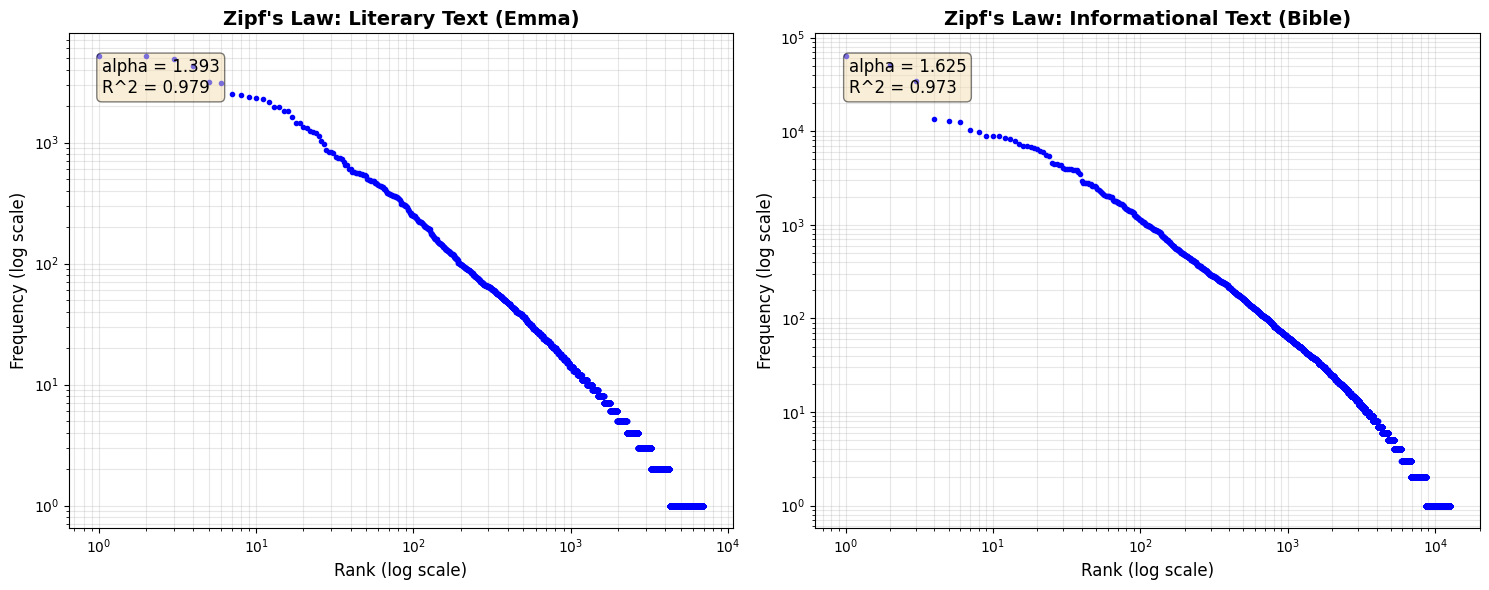

  Plots saved as 'images/zipf_comparison.png'
  [Image Data] Literary: alpha = 1.393, R^2 = 0.979
  [Image Data] Informational: alpha = 1.625, R^2 = 0.973


In [12]:
print("\nStep 4 (continued): Plotting Zipf distributions...")

# 在同一张图中用两个子图对比两类文本的 Zipf 分布（log-log）
# 同时在图上标注回归得到的 alpha 与 R^2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_zipf_distribution(lit_df, "Zipf's Law: Literary Text (Emma)", ax1)
ax1.text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
         transform=ax1.transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(info_df, "Zipf's Law: Informational Text (Bible)", ax2)
ax2.text(0.05, 0.95, f'alpha = {info_alpha:.3f}\nR^2 = {info_r2:.3f}', 
         transform=ax2.transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
# 保存图像到 images 目录（若目录不存在，运行时可能需要先创建）
plt.savefig('images/zipf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Plots saved as 'images/zipf_comparison.png'")
# alpha (α): 齐夫定律指数，理想值约为1.0，表示词频随排名下降的速度
# R^2 (R-squared): 决定系数，范围[0,1]，表示线性回归拟合度，越接近1拟合越好
# 结果解读：
# Alpha > 1.0 表示词频下降比标准齐夫定律更快，可能因为词汇丰富度较高
# R^2 > 0.95 说明拟合度极好，验证了齐夫定律在真实文本中的有效性
# 文学文本Alpha较低(1.393)说明词汇分布更集中，信息文本Alpha较高(1.625)说明词汇更分散
print(f"  [Image Data] Literary: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Informational: alpha = {info_alpha:.3f}, R^2 = {info_r2:.3f}")

## Step 6: Stability testing - Remove stopwords


Step 6: Evaluating stability - Removing stopwords...
Tokens after stopword removal: 69693
Zipf metrics without stopwords:
  Alpha: 1.244, R-squared: 0.958
  Change in alpha: -0.149

Generating comparison plot: Original vs Without Stopwords...


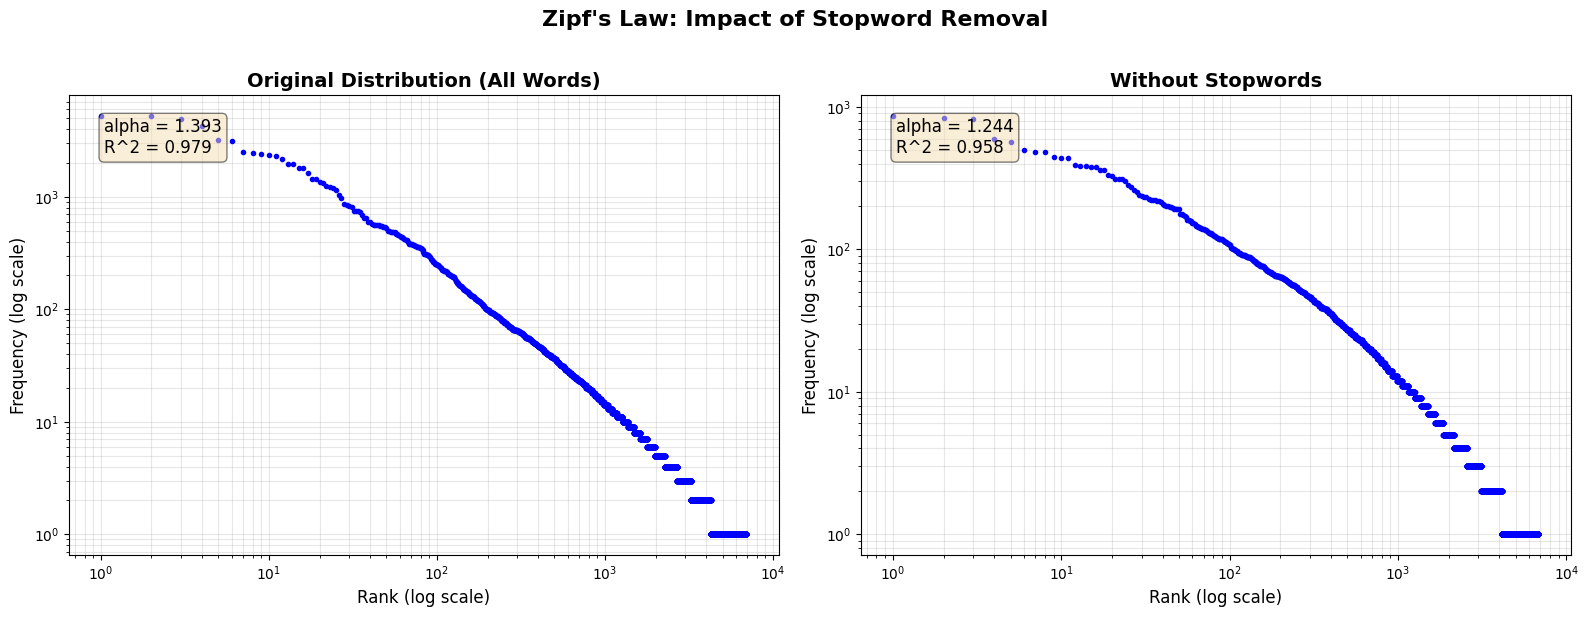

  Comparison plot saved as 'images/zipf_stopword_comparison.png'
  [Image Data] Original: alpha = 1.393, R^2 = 0.979
  [Image Data] Without Stopwords: alpha = 1.244, R^2 = 0.958

Comparison Summary:
  Original:          alpha = 1.393, R^2 = 0.979
  Without Stopwords: alpha = 1.244, R^2 = 0.958
  Change in alpha:   -0.149
  Change in R^2:     -0.020


In [13]:
print("\nStep 6: Evaluating stability - Removing stopwords...")

# 稳定性实验 1：去除停用词
# 目的：观察去掉高频功能词（the/and/of...）后，Zipf 拟合是否仍然成立/参数如何变化

# Use literary text for stability testing
lit_no_stop = remove_stopwords(literary_tokens)
print(f"Tokens after stopword removal: {len(lit_no_stop)}")

# Analyze frequency without stopwords
_, _, lit_no_stop_df = analyze_frequency(lit_no_stop)
no_stop_alpha, no_stop_r2 = calculate_zipf_metrics(lit_no_stop_df)

print(f"Zipf metrics without stopwords:")
print(f"  Alpha: {no_stop_alpha:.3f}, R-squared: {no_stop_r2:.3f}")
print(f"  Change in alpha: {no_stop_alpha - lit_alpha:+.3f}")


# Plot comparison: Original vs Without Stopwords
print("\nGenerating comparison plot: Original vs Without Stopwords...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original distribution
plot_zipf_distribution(lit_df, "Original Distribution (All Words)", axes[0])
axes[0].text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
             transform=axes[0].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Without stopwords
plot_zipf_distribution(lit_no_stop_df, "Without Stopwords", axes[1])
axes[1].text(0.05, 0.95, f'alpha = {no_stop_alpha:.3f}\nR^2 = {no_stop_r2:.3f}', 
             transform=axes[1].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Zipf\'s Law: Impact of Stopword Removal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/zipf_stopword_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Comparison plot saved as 'images/zipf_stopword_comparison.png'")
print(f"  [Image Data] Original: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"\nComparison Summary:")
print(f"  Original:          alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"  Change in alpha:   {no_stop_alpha - lit_alpha:+.3f}")
print(f"  Change in R^2:     {no_stop_r2 - lit_r2:+.3f}")

## Step 6 (continued): Stability testing - Nouns only


Step 6 (continued): Evaluating stability - Nouns only...
Noun tokens extracted: 28185
Zipf metrics for nouns only:
  Alpha: 1.160, R-squared: 0.961
  Change in alpha: -0.233

Plotting stability comparison...


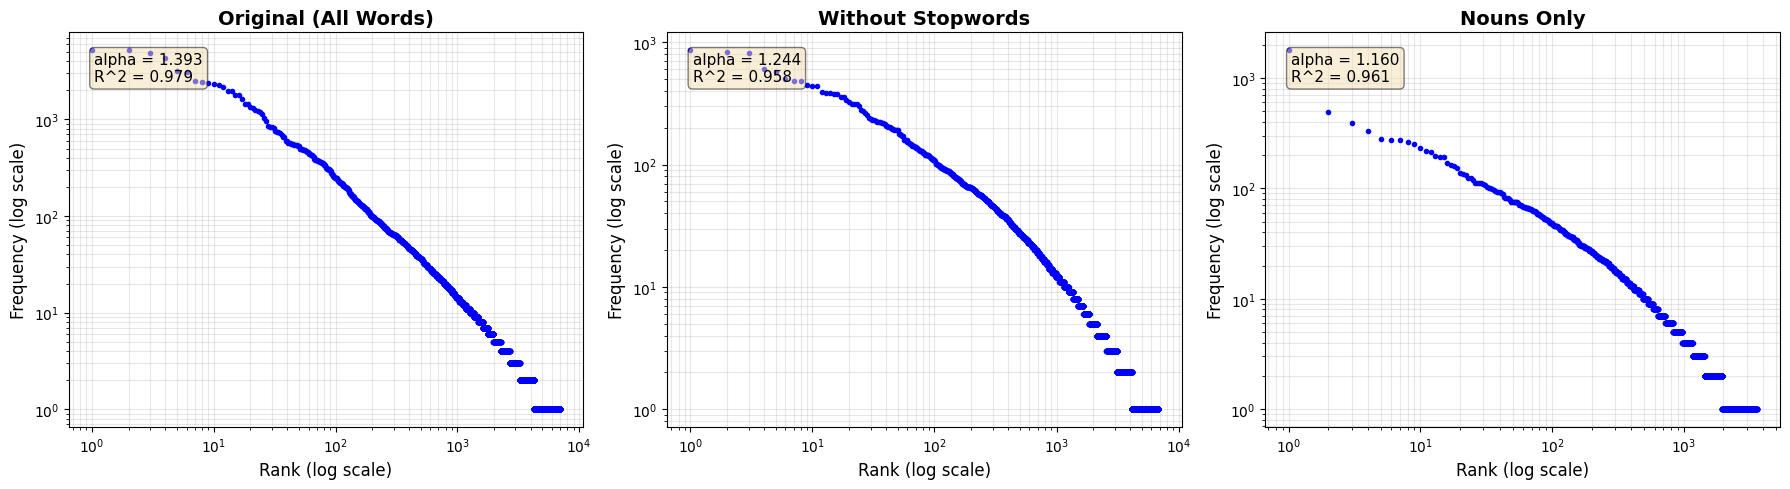

  Stability plots saved as 'images/zipf_stability.png'
  [Image Data] Original: alpha = 1.393, R^2 = 0.979
  [Image Data] Without Stopwords: alpha = 1.244, R^2 = 0.958
  [Image Data] Nouns Only: alpha = 1.160, R^2 = 0.961

Analysis Complete!


In [14]:
print("\nStep 6 (continued): Evaluating stability - Nouns only...")

# 稳定性实验 2：仅保留名词
# 目的：观察在内容词（名词）子集上 Zipf 拟合是否仍保持较好线性，以及参数变化

lit_nouns = extract_nouns(literary_tokens)
print(f"Noun tokens extracted: {len(lit_nouns)}")

# Analyze frequency for nouns only
_, _, lit_nouns_df = analyze_frequency(lit_nouns)
nouns_alpha, nouns_r2 = calculate_zipf_metrics(lit_nouns_df)

print(f"Zipf metrics for nouns only:")
print(f"  Alpha: {nouns_alpha:.3f}, R-squared: {nouns_r2:.3f}")
print(f"  Change in alpha: {nouns_alpha - lit_alpha:+.3f}")


# Plot stability comparison
print("\nPlotting stability comparison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_zipf_distribution(lit_df, "Original (All Words)", axes[0])
axes[0].text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
             transform=axes[0].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(lit_no_stop_df, "Without Stopwords", axes[1])
axes[1].text(0.05, 0.95, f'alpha = {no_stop_alpha:.3f}\nR^2 = {no_stop_r2:.3f}', 
             transform=axes[1].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(lit_nouns_df, "Nouns Only", axes[2])
axes[2].text(0.05, 0.95, f'alpha = {nouns_alpha:.3f}\nR^2 = {nouns_r2:.3f}', 
             transform=axes[2].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('images/zipf_stability.png', dpi=300, bbox_inches='tight')
plt.show()

# Original（α = 1.393, R² = 0.979）：
# 在完整语料中词频分布高度符合 Zipf 定律，且由高频功能词主导，呈现出非常陡峭的幂律结构。
# Without Stopwords（α = 1.244, R² = 0.958）：
# 移除停用词后幂律分布仍然存在，但高频词的削弱使分布变得更平缓、拟合度略有下降。
#Nouns Only（α = 1.160, R² = 0.961）：
# 仅保留名词时词频分布最为分散，说明 Zipf 定律的强度依赖于多词性混合而非单一词类。
print("  Stability plots saved as 'images/zipf_stability.png'")
print(f"  [Image Data] Original: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"  [Image Data] Nouns Only: alpha = {nouns_alpha:.3f}, R^2 = {nouns_r2:.3f}")


print("\n" + "=" * 70)
print("Analysis Complete!")
print("=" * 70)